# FoodMatchMLT: Multi-Task Learning for Food Ingredient Matching — Experiment Report

This notebook presents a data-backed comparison of local experiment results for matching free-form Japanese food ingredient names to canonical entries in the **Standard Tables of Food Composition in Japan**.

## Task Description

Given a free-form Japanese ingredient name (e.g., from a recipe or nutritional label), the system must identify the most appropriate canonical food entry. This is a retrieval / classification task over ~2,541 food items.

## FoodMatchMLT Task Settings

**FoodMatchMLT** fine-tunes encoder models with up to three task combinations:

| Mode | Description |
|---|---|
| `only_id` | ID retrieval only (Task 1) |
| `id_cat` | Task 1 + category supervision (Task 2) |
| `id_tax` | Task 1 + taxonomy supervision (Task 3) |
| `multitask` | Task 1 + Task 2 + Task 3 |

Encoders evaluated: **SBERT** (`sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2`), **E5-large** (`intfloat/multilingual-e5-large`), and **Qwen3:8B** (`Qwen/Qwen3-Embedding-8B`).

## Comparison Setting

This notebook loads the full local comparison results, but the **main table and main figure in this version use a backbone-fixed view**. For each encoder backbone, the report compares:

- **Backbone + Cos**
- **Backbone + Cos + Llama3**
- **Backbone + Cos + Mistral**
- **Backbone + Cos + Qwen3**
- **Backbone + FoodMatchMLT (Ours)**

The backbone-fixed views are reported for **SBERT**, **E5-large**, and **Qwen3:8B**.

## Evaluation Metrics

- **ID matching**: `Acc@1 (ID)`, `Acc@10 (ID)`
- **Category matching**: `Acc@1 (Cat)`, `Acc@10 (Cat)`

## Notes

- The report uses `Acc@1 (ID)` instead of `EM`.
- RAG results are loaded from the completed `k=10` local result files; smoke-test JSON files are excluded.
- FoodMatchMLT selection follows the ablation conclusion: `multitask` for SBERT / E5-large, and `id_tax` for Qwen3:8B.
- FoodMatchMLT rows are loaded from the targeted task-sweep summary files used in the ablation figure.
- The rerun evaluation now stores both `Acc@10` metrics and test-time query embeddings.

---
## Section 1: Setup

In [1]:
import json
import math
import re
import os
import warnings
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.manifold import TSNE

warnings.filterwarnings("ignore")

# ── Global style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})
sns.set_style("whitegrid")

# ── Project root ──────────────────────────────────────────────────────────────
def find_project_root(start: Path) -> Path:
    for candidate in [start] + list(start.parents):
        if (candidate / "src").exists() and (candidate / "notebook").exists():
            return candidate
    raise FileNotFoundError(f"Could not locate project root from: {start}")


def remap_legacy_result_path(path_like) -> Path:
    path = Path(path_like)
    if path.is_absolute():
        return path
    text = path.as_posix()
    if text.startswith("src/ours_v2/"):
        text = text.replace("src/ours_v2/", "src/FoodMatchMTL/", 1)
    return PROJECT_ROOT / text


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
ARTIFACT_DIR = PROJECT_ROOT / "notebook" / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# ── Food category mapping (first 2 digits of zero-padded 5-digit food ID) ─────
CAT_NAMES = {
    "01": "Cereals",
    "02": "Potatoes/Starches",
    "03": "Sugars",
    "04": "Legumes",
    "05": "Nuts & Seeds",
    "06": "Vegetables",
    "07": "Fruits",
    "08": "Mushrooms",
    "09": "Seaweed",
    "10": "Fish & Seafood",
    "11": "Meat",
    "12": "Eggs",
    "13": "Dairy",
    "14": "Oils & Fats",
    "15": "Confectionery",
    "16": "Beverages",
    "17": "Seasonings",
    "18": "Prepared Foods",
}

# ── Helper functions ───────────────────────────────────────────────────────────

def normalize_food_id(value):
    """Normalize a food ID to a clean string."""
    if value is None:
        return None
    if isinstance(value, bool):
        return str(int(value))
    if isinstance(value, int):
        return str(value)
    if isinstance(value, float):
        if math.isnan(value):
            return None
        return str(int(value)) if value.is_integer() else str(value)
    text = str(value).strip()
    if not text or text.lower() in {"none", "null", "nan"}:
        return None
    if re.fullmatch(r"\d+\.0+", text):
        return text.split(".", 1)[0]
    return text


def extract_pred_id(record):
    """Extract predicted food ID from a result record."""
    response = record.get("response")
    if isinstance(response, dict):
        pred = response.get("id") or response.get("food_code")
        return normalize_food_id(pred)
    if isinstance(response, str):
        # Try to parse JSON snippets
        for snippet in [response] + re.findall(r"\{[^{}]*\}", response):
            try:
                parsed = json.loads(snippet.strip())
                if isinstance(parsed, dict):
                    maybe_id = parsed.get("id") or parsed.get("food_code")
                    if maybe_id is not None:
                        return normalize_food_id(maybe_id)
            except Exception:
                pass
        for pat in [r'"id"\s*:\s*"?(\d+)"?', r'"food_code"\s*:\s*"?(\d+)"?']:
            m = re.search(pat, response, re.IGNORECASE)
            if m:
                return normalize_food_id(m.group(1))
    return None


def extract_ranked_ids(record):
    """Extract ranked candidate food IDs from a result record."""
    ranked = []
    for cand in (record.get("top10_candidates") or []):
        if isinstance(cand, dict):
            cid = normalize_food_id(cand.get("id") or cand.get("food_code"))
            if cid:
                ranked.append(cid)
    for cand in (record.get("candidates_topk") or []):
        if isinstance(cand, dict):
            cid = normalize_food_id(cand.get("food_code") or cand.get("id"))
            if cid:
                ranked.append(cid)
    if not ranked:
        pred = extract_pred_id(record)
        if pred:
            ranked = [pred]
    # Deduplicate while preserving order
    seen, out = set(), []
    for cid in ranked:
        if cid not in seen:
            seen.add(cid)
            out.append(cid)
    return out


def food_category(food_id):
    """Return the first 2 digits of a zero-padded 5-digit food ID (category code)."""
    return str(food_id).zfill(5)[:2]


def compute_metrics_from_records(records):
    """Compute Acc@1 and Acc@10 for both ID and Category matching."""
    n = 0
    acc1_id = 0
    acc10_id = 0
    acc1_cat = 0
    acc10_cat = 0
    for rec in records:
        gold = normalize_food_id(rec.get("foodtable_maping"))
        if gold is None:
            continue
        n += 1
        pred = extract_pred_id(rec)
        ranked = extract_ranked_ids(rec)
        gold_cat = food_category(gold)

        if pred and pred == gold:
            acc1_id += 1
        if pred and food_category(pred) == gold_cat:
            acc1_cat += 1
        if gold in ranked[:10]:
            acc10_id += 1
        if any(food_category(r) == gold_cat for r in ranked[:10]):
            acc10_cat += 1

    if n == 0:
        return None
    return {
        "n": n,
        "Acc@1 (ID)": acc1_id / n,
        "Acc@10 (ID)": acc10_id / n,
        "Acc@1 (Cat)": acc1_cat / n,
        "Acc@10 (Cat)": acc10_cat / n,
    }


def load_json_records(path):
    """Load JSON result file; returns list of records."""
    path = Path(path)
    if not path.exists():
        print(f"  [WARNING] File not found: {path}")
        return None
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    # Handle both list and dict-of-list formats
    if isinstance(data, list):
        return data
    if isinstance(data, dict):
        for key in ("results", "items", "data"):
            if key in data and isinstance(data[key], list):
                return data[key]
        # Fallback: return values if they are dicts
        vals = list(data.values())
        if vals and isinstance(vals[0], dict):
            return vals
    return None


print("Setup complete. PROJECT_ROOT =", PROJECT_ROOT)

Setup complete. PROJECT_ROOT = /home/miluser/yoshimaru_env/Ingredient-matching/FoodMatchMTL


---
## Section 2: Load Comparison Results

This section loads local result files for Rule-based, BM25, Embedding+Cos, and LLM (RAG).
For RAG, the report uses the completed `k=10` result file for each LLM / retriever pair.

The full result pool is loaded first, and the main comparison view later reorganizes it into **backbone-fixed selector comparisons** for SBERT, E5-large, and Qwen3:8B.

In [2]:
def response_type_counts(records):
    counts = {"dict": 0, "str": 0, "none": 0, "other": 0}
    for rec in records:
        response = rec.get("response")
        if response is None:
            counts["none"] += 1
        elif isinstance(response, dict):
            counts["dict"] += 1
        elif isinstance(response, str):
            counts["str"] += 1
        else:
            counts["other"] += 1
    return counts


# ── Define all comparison configurations ──────────────────────────────────────
BASELINE_CONFIGS = [
    ("Rule-based",     "—",                    PROJECT_ROOT / "src/baseline/rulebase/res/rulebase/ingredient_matching_rulebase.json"),
    ("BM25",           "—",                    PROJECT_ROOT / "src/baseline/bm25/res/bm25/ingredient_matching_bm25.json"),
    ("LLM (RAG)",      "Llama3.1 / SBERT",     PROJECT_ROOT / "src/baseline/rag/res/llama3_1_7b_hf/sentence_bert/ingredient_matching_rag_k10.json"),
    ("LLM (RAG)",      "Llama3.1 / E5-large",  PROJECT_ROOT / "src/baseline/rag/res/llama3_1_7b_hf/multilingual_e5_large/ingredient_matching_rag_k10.json"),
    ("LLM (RAG)",      "Llama3.1 / Qwen3:8B",  PROJECT_ROOT / "src/baseline/rag/res/llama3_1_7b_hf/qwen3_8b/ingredient_matching_rag_k10.json"),
    ("LLM (RAG)",      "Mistral / SBERT",      PROJECT_ROOT / "src/baseline/rag/res/mistral_hf/sentence_bert/ingredient_matching_rag_k10.json"),
    ("LLM (RAG)",      "Mistral / E5-large",   PROJECT_ROOT / "src/baseline/rag/res/mistral_hf/multilingual_e5_large/ingredient_matching_rag_k10.json"),
    ("LLM (RAG)",      "Mistral / Qwen3:8B",   PROJECT_ROOT / "src/baseline/rag/res/mistral_hf/qwen3_8b/ingredient_matching_rag_k10.json"),
    ("LLM (RAG)",      "Qwen3:8B / SBERT",     PROJECT_ROOT / "src/baseline/rag/res/qwen3_8b_hf/sentence_bert/ingredient_matching_rag_k10.json"),
    ("LLM (RAG)",      "Qwen3:8B / E5-large",  PROJECT_ROOT / "src/baseline/rag/res/qwen3_8b_hf/multilingual_e5_large/ingredient_matching_rag_k10.json"),
    ("LLM (RAG)",      "Qwen3:8B / Qwen3:8B",  PROJECT_ROOT / "src/baseline/rag/res/qwen3_8b_hf/qwen3_8b/ingredient_matching_rag_k10.json"),
    ("Embedding+Cos",  "SBERT",                PROJECT_ROOT / "src/baseline/embedding/res/sentence_bert/ingredient_matching_sentence_bert.json"),
    ("Embedding+Cos",  "E5-large",             PROJECT_ROOT / "src/baseline/embedding/res/multilingual_e5_large/ingredient_matching_multilingual_e5_large.json"),
    ("Embedding+Cos",  "Qwen3:8B",             PROJECT_ROOT / "src/baseline/embedding/res/qwen3_8b/ingredient_matching_qwen3_8b.json"),
]

# ── Load all comparison rows ──────────────────────────────────────────────────
baseline_rows = []

for method, model, path in BASELINE_CONFIGS:
    label = f"{method} / {model}"
    print(f"Loading: {label} ...")
    records = load_json_records(path)

    if records is None:
        print(f"  [SKIP] No records loaded for {label}")
        continue

    metrics = compute_metrics_from_records(records)
    if metrics is None:
        print(f"  [SKIP] Could not compute metrics for {label}")
        continue

    row = {
        "Method": method,
        "Model": model,
        "n": metrics["n"],
        "Acc@1 (ID)": metrics["Acc@1 (ID)"],
        "Acc@10 (ID)": metrics["Acc@10 (ID)"],
        "Acc@1 (Cat)": metrics["Acc@1 (Cat)"],
        "Acc@10 (Cat)": metrics["Acc@10 (Cat)"],
        "Source": str(path.relative_to(PROJECT_ROOT)),
    }
    baseline_rows.append(row)

    print(
        f"  n={metrics['n']}  Acc@1(ID)={metrics['Acc@1 (ID)']:.4f}  "
        f"Acc@10(ID)={metrics['Acc@10 (ID)']:.4f}  "
        f"Acc@1(Cat)={metrics['Acc@1 (Cat)']:.4f}  "
        f"Acc@10(Cat)={metrics['Acc@10 (Cat)']:.4f}"
    )

    if method == "LLM (RAG)":
        stats = response_type_counts(records)
        print(
            "  response types: "
            f"dict={stats['dict']} str={stats['str']} none={stats['none']} other={stats['other']}"
        )

print(f"\nLoaded {len(baseline_rows)} comparison rows.")


Loading: Rule-based / — ...
  n=576  Acc@1(ID)=0.0573  Acc@10(ID)=0.1094  Acc@1(Cat)=0.1215  Acc@10(Cat)=0.3507
Loading: BM25 / — ...
  n=576  Acc@1(ID)=0.4896  Acc@10(ID)=0.7899  Acc@1(Cat)=0.7795  Acc@10(Cat)=0.8438
Loading: LLM (RAG) / Llama3.1 / SBERT ...
  n=576  Acc@1(ID)=0.2118  Acc@10(ID)=0.2847  Acc@1(Cat)=0.4549  Acc@10(Cat)=0.6372
  response types: dict=576 str=0 none=0 other=0
Loading: LLM (RAG) / Llama3.1 / E5-large ...
  n=576  Acc@1(ID)=0.5312  Acc@10(ID)=0.7812  Acc@1(Cat)=0.8889  Acc@10(Cat)=0.9444
  response types: dict=576 str=0 none=0 other=0
Loading: LLM (RAG) / Llama3.1 / Qwen3:8B ...
  n=576  Acc@1(ID)=0.2830  Acc@10(ID)=0.3628  Acc@1(Cat)=0.6163  Acc@10(Cat)=0.6962
  response types: dict=576 str=0 none=0 other=0
Loading: LLM (RAG) / Mistral / SBERT ...
  n=576  Acc@1(ID)=0.0000  Acc@10(ID)=0.2847  Acc@1(Cat)=0.0017  Acc@10(Cat)=0.6372
  response types: dict=7 str=0 none=569 other=0
Loading: LLM (RAG) / Mistral / E5-large ...
  n=576  Acc@1(ID)=0.0000  Acc@10(ID)

---
## Section 3: FoodMatchMLT Results (Proposed Method)

This section applies the ablation-guided mode selection used in the report:

- **SBERT**: `multitask`
- **E5-large**: `multitask`
- **Qwen3:8B**: `id_tax`

For each encoder, the notebook loads the run selected from the targeted task-sweep summary file used in the ablation figure.
Because the rerun evaluation now stores top-k retrieval results, both `Acc@1` and `Acc@10` are reported here.


In [3]:
# ── FoodMatchMLT selected results (ablation-guided mode choice) ───────────────

FOODMATCH_ORDER = ["SBERT", "E5-large", "Qwen3:8B"]
FOODMATCH_TARGET_MODES = {
    "SBERT": "multitask",
    "E5-large": "multitask",
    "Qwen3:8B": "id_tax",
}
FOODMATCH_SUMMARY_FILES = {
    "SBERT": PROJECT_ROOT / "src/FoodMatchMTL/results/proj_head_ablation/task1_mode_sweep_20260322_062433_seed42_summary.json",
    "E5-large": PROJECT_ROOT / "src/FoodMatchMTL/results/model3_weight6_task4_gpu2/task1_mode_sweep_20260216_203304_seed42_summary.json",
    "Qwen3:8B": PROJECT_ROOT / "src/FoodMatchMTL/results/proj_head_ablation/task1_mode_sweep_20260322_003103_seed42_summary.json",
}


def find_latest_matching_run(summary_path, target_mode, encoder_name):
    root_dir = summary_path.parent
    candidates = []
    for config_path in root_dir.glob("2026*_*/config.json"):
        try:
            cfg = json.loads(config_path.read_text(encoding="utf-8"))
        except Exception:
            continue
        args = cfg.get("args", {})
        if args.get("mode") != target_mode:
            continue
        if cfg.get("encoder_name") != encoder_name:
            continue
        eval_path = config_path.parent / "eval_result.json"
        if not eval_path.exists():
            continue
        try:
            payload = json.loads(eval_path.read_text(encoding="utf-8"))
            metrics = payload.get("metrics", {})
        except Exception:
            continue
        if "Acc@10_ID" not in metrics or "Acc@10_Category" not in metrics:
            continue
        candidates.append(config_path.parent)
    if not candidates:
        return None
    return sorted(candidates)[-1]


def resolve_selected_run(summary_path, target_mode):
    payload = json.loads(summary_path.read_text(encoding="utf-8"))
    selected = None
    for row in payload.get("results", []):
        if row.get("mode") == target_mode:
            selected = row
            break
    if selected is None:
        raise RuntimeError(f"Missing mode={target_mode} in {summary_path}")

    preferred_run_dir = remap_legacy_result_path(selected["run_dir"])
    encoder_name = selected.get("encoder_name")

    eval_path = preferred_run_dir / "eval_result.json"
    if eval_path.exists():
        try:
            eval_payload = json.loads(eval_path.read_text(encoding="utf-8"))
            metrics = eval_payload.get("metrics", {})
            if "Acc@10_ID" in metrics and "Acc@10_Category" in metrics:
                return preferred_run_dir
        except Exception:
            pass

    latest_run = find_latest_matching_run(summary_path, target_mode, encoder_name)
    if latest_run is None:
        raise RuntimeError(f"No rerun with Acc@10 found for mode={target_mode} encoder={encoder_name}")
    return latest_run


def load_selected_foodmatch_results(summary_files):
    rows = []

    for encoder_label in FOODMATCH_ORDER:
        summary_path = Path(summary_files[encoder_label])
        target_mode = FOODMATCH_TARGET_MODES[encoder_label]
        run_dir = resolve_selected_run(summary_path, target_mode)
        eval_path = run_dir / "eval_result.json"
        eval_payload = json.loads(eval_path.read_text(encoding="utf-8"))
        metrics = eval_payload.get("metrics", {})
        acc1_id = metrics.get("Acc@1_ID", metrics.get("EM"))
        acc10_id = metrics.get("Acc@10_ID")
        acc1_cat = metrics.get("Acc@1_Category", metrics.get("CategoryMatch"))
        acc10_cat = metrics.get("Acc@10_Category")
        if acc1_id is None or acc10_id is None or acc1_cat is None or acc10_cat is None:
            raise RuntimeError(f"Missing Acc@k metrics in {eval_path}")

        per_item = eval_payload.get("per_item")
        if isinstance(per_item, list):
            n_eval = len(per_item)
        else:
            n_eval = eval_payload.get("meta", {}).get("dataset_sizes", {}).get("eval_unique_ingredients", 576)

        rows.append(
            {
                "Method": "FoodMatchMLT",
                "Model": encoder_label,
                "n": n_eval,
                "Acc@1 (ID)": float(acc1_id),
                "Acc@10 (ID)": float(acc10_id),
                "Acc@1 (Cat)": float(acc1_cat),
                "Acc@10 (Cat)": float(acc10_cat),
                "Selected mode": target_mode,
                "Source": str(eval_path.relative_to(PROJECT_ROOT)),
                "Summary": str(summary_path.relative_to(PROJECT_ROOT)),
            }
        )

    return rows


foodmatch_results = load_selected_foodmatch_results(FOODMATCH_SUMMARY_FILES)

print("FoodMatchMLT results (ablation-guided mode selection):")
for row in foodmatch_results:
    print(
        f"  {row['Model']:12s}  mode={row['Selected mode']:10s}  "
        f"Acc@1(ID)={row['Acc@1 (ID)']:.4f}  "
        f"Acc@10(ID)={row['Acc@10 (ID)']:.4f}  "
        f"Acc@1(Cat)={row['Acc@1 (Cat)']:.4f}  "
        f"Acc@10(Cat)={row['Acc@10 (Cat)']:.4f}  "
        f"source={row['Source']}"
    )


FoodMatchMLT results (ablation-guided mode selection):
  SBERT         mode=multitask   Acc@1(ID)=0.4549  Acc@10(ID)=0.7587  Acc@1(Cat)=0.7726  Acc@10(Cat)=0.9462  source=src/FoodMatchMTL/results/proj_head_ablation/20260324_022947_multitask_sentence_bert_lr1e-05_bs8_a0.05_b0.1_seed42/eval_result.json
  E5-large      mode=multitask   Acc@1(ID)=0.4948  Acc@10(ID)=0.8108  Acc@1(Cat)=0.8229  Acc@10(Cat)=0.9688  source=src/FoodMatchMTL/results/model3_weight6_task4_gpu2/20260324_034636_multitask_multilingual_e5_large_lr1e-05_bs8_a0.08_b0.12_seed42/eval_result.json
  Qwen3:8B      mode=id_tax      Acc@1(ID)=0.5729  Acc@10(ID)=0.9167  Acc@1(Cat)=0.9306  Acc@10(Cat)=0.9965  source=src/FoodMatchMTL/results/proj_head_ablation/20260325_230433_id_tax_qwen3_8b_lr1e-05_bs8_a0.05_b0.1_seed42/eval_result.json


---
## Section 4: Main Comparison Table (Backbone-Fixed View: SBERT / E5-large / Qwen3:8B)

In [ ]:
from IPython.display import display

# ── Combine comparison rows + FoodMatchMLT ────────────────────────────────────
all_rows = baseline_rows + foodmatch_results
df_all = pd.DataFrame(all_rows)

METRIC_COLS = ["Acc@1 (ID)", "Acc@10 (ID)", "Acc@1 (Cat)", "Acc@10 (Cat)"]
BACKBONE_ORDER = ["SBERT", "E5-large", "Qwen3:8B"]
SELECTOR_ORDER = ["Cos", "Cos + Llama3", "Cos + Mistral", "Cos + Qwen3", "FoodMatchMLT (Ours)"]
SELECTOR_SHORT = {
    "Cos": "Cos",
    "Cos + Llama3": "Llama3",
    "Cos + Mistral": "Mistral",
    "Cos + Qwen3": "Qwen3",
    "FoodMatchMLT (Ours)": "Ours",
}
TABLE_BACKBONE_ORDER = ["Common", "SBERT", "E5-large", "Qwen3:8B"]
BACKBONE_ROW_COLORS = {
    "Common": "#F0F0F0",
    "SBERT": "#F5F5F5",
    "E5-large": "#FFF8E8",
    "Qwen3:8B": "#EEF6FF",
}

BASELINE_TOP_CONFIG = [
    {"Method": "Rule-based", "Model": "—", "Backbone": "Common", "Configuration": "Rule-based (alias_dict)", "Selector": "Rule-based", "Selector Short": "Rule"},
    {"Method": "BM25", "Model": "—", "Backbone": "Common", "Configuration": "BM25 (2-gram)", "Selector": "BM25", "Selector Short": "BM25"},
]

FOCUS_COMPARISON_CONFIG = {
    "SBERT": [
        {"Method": "Embedding+Cos", "Model": "SBERT", "Selector": "Cos", "Configuration": "SBERT + Cos"},
        {"Method": "LLM (RAG)", "Model": "Llama3.1 / SBERT", "Selector": "Cos + Llama3", "Configuration": "SBERT + Cos + Llama3"},
        {"Method": "LLM (RAG)", "Model": "Mistral / SBERT", "Selector": "Cos + Mistral", "Configuration": "SBERT + Cos + Mistral"},
        {"Method": "LLM (RAG)", "Model": "Qwen3:8B / SBERT", "Selector": "Cos + Qwen3", "Configuration": "SBERT + Cos + Qwen3"},
        {"Method": "FoodMatchMLT", "Model": "SBERT", "Selector": "FoodMatchMLT (Ours)", "Configuration": "SBERT + FoodMatchMLT (Ours)"},
    ],
    "E5-large": [
        {"Method": "Embedding+Cos", "Model": "E5-large", "Selector": "Cos", "Configuration": "E5 + Cos"},
        {"Method": "LLM (RAG)", "Model": "Llama3.1 / E5-large", "Selector": "Cos + Llama3", "Configuration": "E5 + Cos + Llama3"},
        {"Method": "LLM (RAG)", "Model": "Mistral / E5-large", "Selector": "Cos + Mistral", "Configuration": "E5 + Cos + Mistral"},
        {"Method": "LLM (RAG)", "Model": "Qwen3:8B / E5-large", "Selector": "Cos + Qwen3", "Configuration": "E5 + Cos + Qwen3"},
        {"Method": "FoodMatchMLT", "Model": "E5-large", "Selector": "FoodMatchMLT (Ours)", "Configuration": "E5 + FoodMatchMLT (Ours)"},
    ],
    "Qwen3:8B": [
        {"Method": "Embedding+Cos", "Model": "Qwen3:8B", "Selector": "Cos", "Configuration": "Qwen3 + Cos"},
        {"Method": "LLM (RAG)", "Model": "Llama3.1 / Qwen3:8B", "Selector": "Cos + Llama3", "Configuration": "Qwen3 + Cos + Llama3"},
        {"Method": "LLM (RAG)", "Model": "Mistral / Qwen3:8B", "Selector": "Cos + Mistral", "Configuration": "Qwen3 + Cos + Mistral"},
        {"Method": "LLM (RAG)", "Model": "Qwen3:8B / Qwen3:8B", "Selector": "Cos + Qwen3", "Configuration": "Qwen3 + Cos + Qwen3"},
        {"Method": "FoodMatchMLT", "Model": "Qwen3:8B", "Selector": "FoodMatchMLT (Ours)", "Configuration": "Qwen3 + FoodMatchMLT (Ours)"},
    ],
}

focus_rows = []
for cfg in BASELINE_TOP_CONFIG:
    matched = df_all[(df_all["Method"] == cfg["Method"]) & (df_all["Model"] == cfg["Model"])]
    if matched.empty:
        raise RuntimeError(f"Missing comparison row for {cfg['Method']} / {cfg['Model']}")
    if len(matched) > 1:
        raise RuntimeError(f"Duplicate comparison rows for {cfg['Method']} / {cfg['Model']}")

    row = matched.iloc[0].to_dict()
    row["Backbone"] = cfg["Backbone"]
    row["Selector"] = cfg["Selector"]
    row["Configuration"] = cfg["Configuration"]
    row["Selector Short"] = cfg["Selector Short"]
    focus_rows.append(row)

for backbone in BACKBONE_ORDER:
    for cfg in FOCUS_COMPARISON_CONFIG[backbone]:
        matched = df_all[(df_all["Method"] == cfg["Method"]) & (df_all["Model"] == cfg["Model"])]
        if matched.empty:
            raise RuntimeError(f"Missing comparison row for {cfg['Method']} / {cfg['Model']}")
        if len(matched) > 1:
            raise RuntimeError(f"Duplicate comparison rows for {cfg['Method']} / {cfg['Model']}")

        row = matched.iloc[0].to_dict()
        row["Backbone"] = backbone
        row["Selector"] = cfg["Selector"]
        row["Configuration"] = cfg["Configuration"]
        row["Selector Short"] = SELECTOR_SHORT[cfg["Selector"]]
        focus_rows.append(row)

df_focus = pd.DataFrame(focus_rows)
df_focus["Backbone"] = pd.Categorical(df_focus["Backbone"], categories=TABLE_BACKBONE_ORDER, ordered=True)
df_focus = df_focus.reset_index(drop=True)

# ── Display evaluation dataframe ──────────────────────────────────────────────
df_display = df_focus[["Backbone", "Configuration", "Selector Short"] + METRIC_COLS].copy()
df_display = df_display.rename(columns={"Selector Short": "Selector"})
for col in METRIC_COLS:
    df_display[col] = pd.to_numeric(df_display[col], errors="coerce").map(lambda v: f"{v:.4f}")

display(df_display)

print()
print("Plain-text summary:")
print(df_display.to_string(index=False))

In [5]:
# ── Export the table as a plain dataframe / CSV (no table figure) ────────────
df_table_export = df_focus[["Backbone", "Configuration", "Selector"] + METRIC_COLS].copy()
for col in METRIC_COLS:
    df_table_export[col] = pd.to_numeric(df_table_export[col], errors="coerce").map(lambda v: f"{v:.4f}")

csv_path = ARTIFACT_DIR / "table1_comparison.csv"
df_table_export.to_csv(csv_path, index=False)
print(f"Saved dataframe CSV: {csv_path.relative_to(PROJECT_ROOT)}")

Saved dataframe CSV: notebook/artifacts/table1_comparison.csv


---
## Section 5: Figure 1 — Backbone-Fixed Comparison Bar Charts (Acc@1 by Selector)

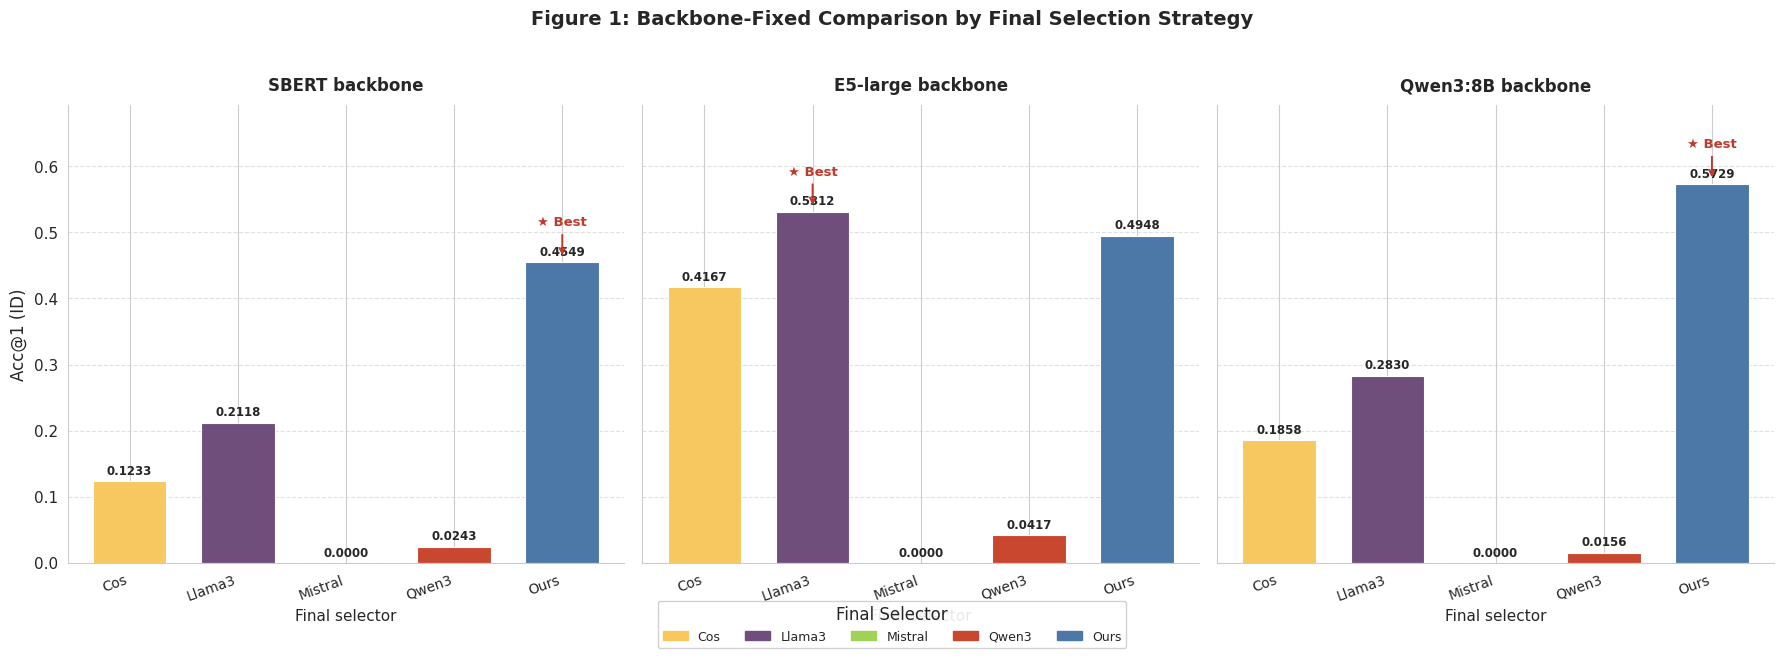

Saved: figure1_acc1_comparison.png


In [6]:
# ── Figure 1: Bar charts — ID Acc@1 for each fixed backbone ──────────────────

selector_palette = {
    "Cos":                 "#F6C85F",
    "Cos + Llama3":        "#6F4E7C",
    "Cos + Mistral":       "#9FD356",
    "Cos + Qwen3":         "#CA472F",
    "FoodMatchMLT (Ours)": "#4C78A8",
}
selector_tick_labels = {
    "Cos": "Cos",
    "Cos + Llama3": "Llama3",
    "Cos + Mistral": "Mistral",
    "Cos + Qwen3": "Qwen3",
    "FoodMatchMLT (Ours)": "Ours",
}

fig1, axes = plt.subplots(1, len(BACKBONE_ORDER), figsize=(18, 6.2), sharey=True)
if len(BACKBONE_ORDER) == 1:
    axes = [axes]

for ax, backbone in zip(axes, BACKBONE_ORDER):
    sub = df_focus[df_focus["Backbone"] == backbone].copy()
    sub = sub.sort_values("Selector")
    sub["Acc@1 (ID) value"] = pd.to_numeric(sub["Acc@1 (ID)"], errors="coerce")

    x_positions = np.arange(len(sub))
    bar_colors = [selector_palette.get(str(s), "#888888") for s in sub["Selector"]]
    bars = ax.bar(
        x_positions,
        sub["Acc@1 (ID) value"],
        color=bar_colors,
        edgecolor="white",
        linewidth=0.8,
        width=0.68,
    )

    for bar, val in zip(bars, sub["Acc@1 (ID) value"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.006,
            f"{val:.4f}",
            ha="center",
            va="bottom",
            fontsize=8.5,
            fontweight="bold",
        )

    best_val = sub["Acc@1 (ID) value"].max()
    best_pos = sub[sub["Acc@1 (ID) value"] == best_val].index[0] - sub.index.min()
    ax.annotate(
        "★ Best",
        xy=(best_pos, best_val + 0.006),
        xytext=(best_pos, best_val + 0.055),
        ha="center",
        fontsize=9.5,
        color="#C0392B",
        fontweight="bold",
        arrowprops=dict(arrowstyle="->", color="#C0392B", lw=1.4),
    )

    ax.set_xticks(x_positions)
    ax.set_xticklabels([selector_tick_labels[str(s)] for s in sub["Selector"]], rotation=20, ha="right", fontsize=10)
    ax.set_title(f"{backbone} backbone", fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Final selector", fontsize=11)
    ax.yaxis.grid(True, linestyle="--", alpha=0.6)
    ax.set_axisbelow(True)
    sns.despine(ax=ax, left=False, bottom=False)

axes[0].set_ylabel("Acc@1 (ID)", fontsize=12)
y_max = pd.to_numeric(df_focus["Acc@1 (ID)"], errors="coerce").max()
axes[0].set_ylim(0, min(1.0, y_max + 0.12))

legend_patches_fig1 = [
    mpatches.Patch(color=color, label=selector_tick_labels[selector])
    for selector, color in selector_palette.items()
]
fig1.legend(
    handles=legend_patches_fig1,
    title="Final Selector",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=5,
    fontsize=9,
    framealpha=0.9,
)
fig1.suptitle(
    "Figure 1: Backbone-Fixed Comparison by Final Selection Strategy",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figure1_acc1_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figure1_acc1_comparison.png")

---
## Section 6: Figure 2 — Ablation Study (Effect of Task Combination)

Selected task-sweep sources for ablation:
  SBERT      src/FoodMatchMTL/results/proj_head_ablation/task1_mode_sweep_20260322_062433_seed42_summary.json
  E5-large   src/FoodMatchMTL/results/model3_weight6_task4_gpu2/task1_mode_sweep_20260216_203304_seed42_summary.json
  Qwen3:8B   src/FoodMatchMTL/results/proj_head_ablation/task1_mode_sweep_20260322_003103_seed42_summary.json


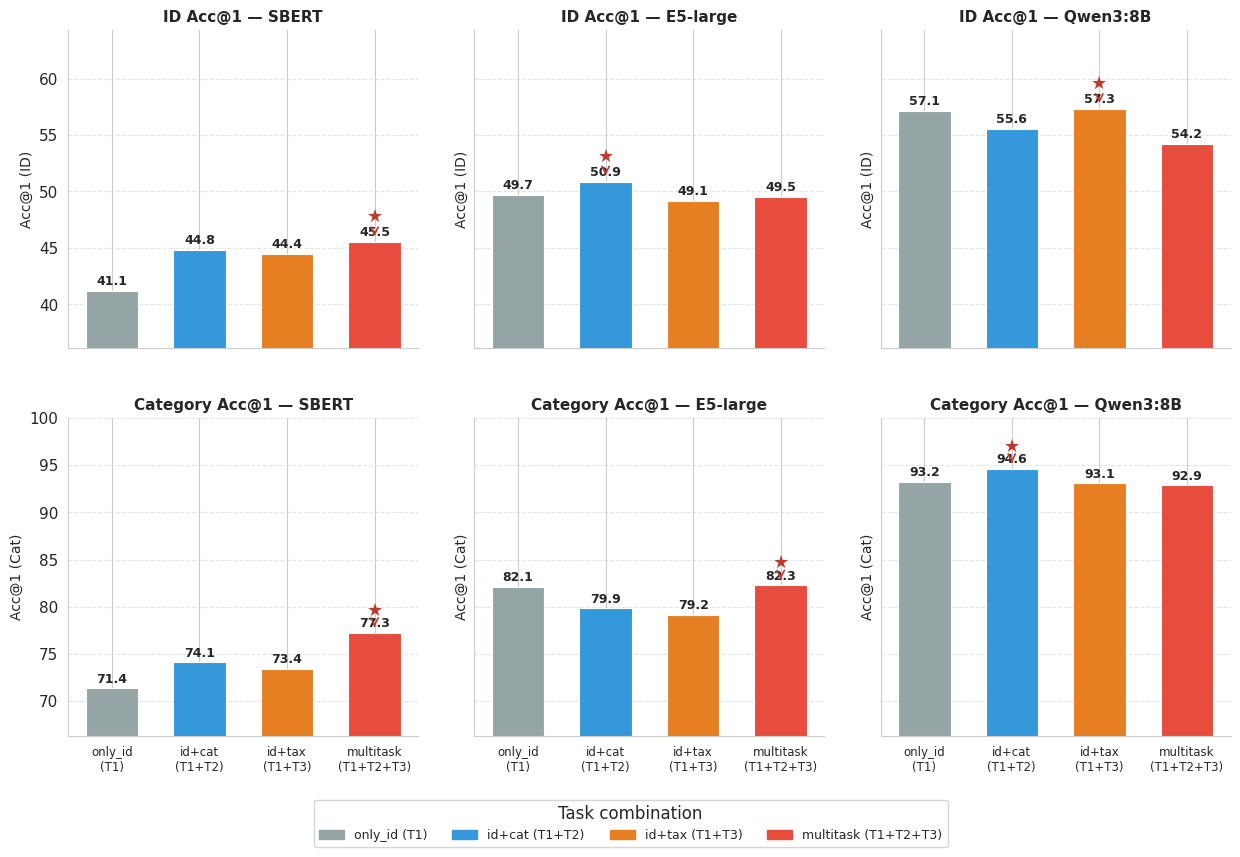

Saved: figure2_ablation.png


In [7]:
# ── Ablation data (task-combination sweeps used for model selection) ──────────

ABLATION_SUMMARY_FILES = {
    "SBERT": PROJECT_ROOT / "src/FoodMatchMTL/results/proj_head_ablation/task1_mode_sweep_20260322_062433_seed42_summary.json",
    "E5-large": PROJECT_ROOT / "src/FoodMatchMTL/results/model3_weight6_task4_gpu2/task1_mode_sweep_20260216_203304_seed42_summary.json",
    "Qwen3:8B": PROJECT_ROOT / "src/FoodMatchMTL/results/proj_head_ablation/task1_mode_sweep_20260322_003103_seed42_summary.json",
}
SWEEP_ORDER = ["SBERT", "E5-large", "Qwen3:8B"]
MODE_ORDER = ["only_id", "id_cat", "id_tax", "multitask"]


def resolve_ablation_metrics(summary_path):
    payload = json.loads(summary_path.read_text(encoding="utf-8"))
    rows = payload.get("results", [])
    by_mode = {row["mode"]: row for row in rows if row.get("mode") in MODE_ORDER}
    if any(mode not in by_mode for mode in MODE_ORDER):
        raise RuntimeError(f"Missing modes in {summary_path}")

    out = {}
    for mode in MODE_ORDER:
        row = by_mode[mode]
        eval_metrics = row.get("eval_metrics") or {}
        if "EM" in eval_metrics and "CategoryMatch" in eval_metrics:
            run_dir = remap_legacy_result_path(row["run_dir"])
            eval_path = run_dir / "eval_result.json"
            if eval_path.exists():
                try:
                    latest_payload = json.loads(eval_path.read_text(encoding="utf-8"))
                    latest_metrics = latest_payload.get("metrics", {})
                    if "EM" in latest_metrics and "CategoryMatch" in latest_metrics:
                        eval_metrics = latest_metrics
                except Exception:
                    pass
        out[mode] = eval_metrics
    return out


def load_ablation_results(summary_files):
    out = {}
    for encoder, summary_path in summary_files.items():
        by_mode = resolve_ablation_metrics(summary_path)
        out[encoder] = {
            "source": str(summary_path.relative_to(PROJECT_ROOT)),
            "em": {mode: by_mode[mode]["EM"] for mode in MODE_ORDER},
            "cat": {mode: by_mode[mode]["CategoryMatch"] for mode in MODE_ORDER},
        }
    return out


sweep_results = load_ablation_results(ABLATION_SUMMARY_FILES)
ablation_data = {encoder: sweep_results[encoder]["em"] for encoder in SWEEP_ORDER}
ablation_cat_data = {encoder: sweep_results[encoder]["cat"] for encoder in SWEEP_ORDER}

print("Selected task-sweep sources for ablation:")
for encoder in SWEEP_ORDER:
    print(f"  {encoder:9s}  {sweep_results[encoder]['source']}")

TASK_DISPLAY = {
    "only_id":   "only_id\n(T1)",
    "id_cat":    "id+cat\n(T1+T2)",
    "id_tax":    "id+tax\n(T1+T3)",
    "multitask": "multitask\n(T1+T2+T3)",
}
TASK_COLORS = {
    "only_id":   "#95A5A6",
    "id_cat":    "#3498DB",
    "id_tax":    "#E67E22",
    "multitask": "#E74C3C",
}

fig2, axes = plt.subplots(2, 3, figsize=(15, 9.8), sharex=True, sharey="row")

row_limits = {}
for row_idx, data_dict in enumerate([ablation_data, ablation_cat_data]):
    row_vals = [
        data_dict[encoder][mode] * 100
        for encoder in SWEEP_ORDER
        for mode in MODE_ORDER
    ]
    row_min = max(0, min(row_vals) - 5)
    row_max = min(100, max(row_vals) + 7)
    row_limits[row_idx] = (row_min, row_max)

for col_idx, encoder in enumerate(SWEEP_ORDER):
    for row_idx, (data_dict, y_label) in enumerate([
        (ablation_data, "Acc@1 (ID)"),
        (ablation_cat_data, "Acc@1 (Cat)"),
    ]):
        ax = axes[row_idx][col_idx]
        vals = [data_dict[encoder][mode] * 100 for mode in MODE_ORDER]
        colors = [TASK_COLORS[mode] for mode in MODE_ORDER]
        x_pos = np.arange(len(MODE_ORDER))
        bars = ax.bar(x_pos, vals, color=colors, edgecolor="white", linewidth=0.8, width=0.6)

        for bar, v in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                f"{v:.1f}",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold",
            )

        best_v = max(vals)
        best_i = vals.index(best_v)
        ax.annotate(
            "★",
            xy=(best_i, best_v + 0.3),
            xytext=(best_i, best_v + 1.8),
            ha="center",
            fontsize=13,
            color="#C0392B",
            fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#C0392B", lw=1.2),
        )

        ax.set_xticks(x_pos)
        ax.set_xlim(-0.5, len(MODE_ORDER) - 0.5)
        ax.set_xticklabels([TASK_DISPLAY[mode] for mode in MODE_ORDER], fontsize=8.5)
        ax.set_ylabel(y_label, fontsize=10)
        row_min, row_max = row_limits[row_idx]
        ax.set_ylim(row_min, row_max)
        ax.yaxis.grid(True, linestyle="--", alpha=0.5)
        ax.set_axisbelow(True)

        title_prefix = "ID" if row_idx == 0 else "Category"
        ax.set_title(f"{title_prefix} Acc@1 — {encoder}", fontsize=11, fontweight="bold")
        sns.despine(ax=ax)

legend_patches_fig2 = [
    mpatches.Patch(color=TASK_COLORS[mode], label=TASK_DISPLAY[mode].replace("\n", " "))
    for mode in MODE_ORDER
]
fig2.legend(
    handles=legend_patches_fig2,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.04),
    ncol=4,
    fontsize=9,
    frameon=True,
    title="Task combination",
)

fig2.subplots_adjust(bottom=0.16, hspace=0.22, wspace=0.16)
plt.savefig(ARTIFACT_DIR / "figure2_ablation.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: figure2_ablation.png")


---
## Section 7: Figure 3 — T-SNE Visualization of Canonical Food Embeddings

The T-SNE plots below show how zero-shot encoder embeddings of the 2,541 canonical food table entries cluster by food category. Better category-level separation correlates with stronger retrieval performance.

> **Note:** Only up to 2,000 randomly sampled items are used for speed. Fine-tuned FoodMatchMLT embeddings would show improved categorical clustering, but require running checkpoint inference (not included here).

In [8]:
MAX_TSNE_ITEMS = 2000
RANDOM_SEED = 42

# ── Load embedding files ───────────────────────────────────────────────────────
sbert_emb_path = PROJECT_ROOT / "src/baseline_embedding/res/sentence_bert/foodtable_embedding_sentence_bert.json"
e5_emb_path    = PROJECT_ROOT / "src/baseline_embedding/res/multilingual_e5_large/foodtable_embedding_multilingual_e5_large.json"


def load_embeddings(path):
    """
    Load food table embeddings from JSON.
    Returns (food_codes, food_names, embeddings_array).
    """
    path = Path(path)
    if not path.exists():
        print(f"  [WARNING] Embedding file not found: {path}")
        return None, None, None
    print(f"Loading embeddings from {path.name} ...")
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    items = data.get("items", [])
    if not items:
        print(f"  [WARNING] No items found in {path.name}")
        return None, None, None
    food_codes = [item["food_code"] for item in items]
    food_names = [item.get("food_name", "") for item in items]
    embeddings  = np.array([item["embedding"] for item in items], dtype=np.float32)
    print(f"  Loaded {len(items)} items, embedding dim={embeddings.shape[1]}")
    return food_codes, food_names, embeddings


sbert_codes, sbert_names, sbert_embs = load_embeddings(sbert_emb_path)
e5_codes,    e5_names,    e5_embs    = load_embeddings(e5_emb_path)

print("\nEmbedding shapes:")
if sbert_embs is not None: print(f"  SBERT:    {sbert_embs.shape}")
if e5_embs    is not None: print(f"  E5-large: {e5_embs.shape}")

  [WARNING] Embedding file not found: /home/miluser/yoshimaru_env/Ingredient-matching/FoodMatchMTL/src/baseline_embedding/res/sentence_bert/foodtable_embedding_sentence_bert.json
  [WARNING] Embedding file not found: /home/miluser/yoshimaru_env/Ingredient-matching/FoodMatchMTL/src/baseline_embedding/res/multilingual_e5_large/foodtable_embedding_multilingual_e5_large.json

Embedding shapes:


In [9]:
def run_tsne_on_embeddings(codes, embeddings, max_items=MAX_TSNE_ITEMS, seed=RANDOM_SEED):
    """Subsample, assign categories, run T-SNE, return (tsne_2d, cat_codes, cat_names_list)."""
    n = len(codes)
    if n > max_items:
        rng = np.random.default_rng(seed)
        idx = rng.choice(n, size=max_items, replace=False)
        idx = np.sort(idx)
    else:
        idx = np.arange(n)

    sub_codes = [codes[i] for i in idx]
    sub_embs  = embeddings[idx]

    # Assign category
    cat_codes = [food_category(c) for c in sub_codes]
    
    print(f"  Running T-SNE on {len(sub_codes)} items ...")
    tsne = TSNE(n_components=2, random_state=seed, perplexity=30, n_iter=1000, verbose=0)
    tsne_2d = tsne.fit_transform(sub_embs)
    print(f"  T-SNE complete. Shape: {tsne_2d.shape}")
    return tsne_2d, cat_codes


# ── Run T-SNE for both encoders ────────────────────────────────────────────────
tsne_results = {}

if sbert_embs is not None:
    print("Running T-SNE on SBERT embeddings ...")
    tsne_sbert, cats_sbert = run_tsne_on_embeddings(sbert_codes, sbert_embs)
    tsne_results["SBERT"] = (tsne_sbert, cats_sbert)

if e5_embs is not None:
    print("\nRunning T-SNE on E5-large embeddings ...")
    tsne_e5, cats_e5 = run_tsne_on_embeddings(e5_codes, e5_embs)
    tsne_results["E5-large"] = (tsne_e5, cats_e5)

print("\nT-SNE computation done.")


T-SNE computation done.


In [10]:
# ── Figure 3: Side-by-side T-SNE plots ────────────────────────────────────────

# Build a sorted list of all category codes present in the data
all_cat_codes = sorted(set(
    (cats_sbert if "SBERT" in tsne_results else []) +
    (cats_e5    if "E5-large" in tsne_results else [])
))

# Assign colors from tab20
cmap_qual = plt.cm.get_cmap("tab20", len(all_cat_codes))
cat_color_map = {code: cmap_qual(i) for i, code in enumerate(all_cat_codes)}

panel_configs = [
    ("SBERT",    "Left: SBERT (zero-shot)\nEmbedding+Cos backbone"),
    ("E5-large", "Right: E5-large (zero-shot)\nEmbedding+Cos / FoodMatchMLT backbone (before fine-tuning)"),
]

n_panels = sum(1 for key, _ in panel_configs if key in tsne_results)

if n_panels == 0:
    print("[WARNING] No T-SNE results available for plotting.")
else:
    fig3, axes3 = plt.subplots(1, n_panels, figsize=(8 * n_panels, 7))
    if n_panels == 1:
        axes3 = [axes3]

    panel_idx = 0
    for enc_key, panel_label in panel_configs:
        if enc_key not in tsne_results:
            continue
        ax = axes3[panel_idx]
        tsne_2d, cat_codes = tsne_results[enc_key]

        # Scatter each category separately so legend is clean
        present_cats = sorted(set(cat_codes))
        for cat_code in present_cats:
            mask = np.array([c == cat_code for c in cat_codes])
            color = cat_color_map[cat_code]
            cat_name = CAT_NAMES.get(cat_code, f"Cat {cat_code}")
            ax.scatter(
                tsne_2d[mask, 0], tsne_2d[mask, 1],
                c=[color], label=f"{cat_code}: {cat_name}",
                alpha=0.6, s=8, linewidths=0,
            )

        ax.set_title(panel_label, fontsize=11, fontweight="bold", pad=10)
        ax.set_xlabel("T-SNE Dim 1", fontsize=10)
        ax.set_ylabel("T-SNE Dim 2", fontsize=10)
        ax.tick_params(labelsize=9)
        sns.despine(ax=ax)

        # Legend inside the panel (small)
        legend = ax.legend(
            title="Food Category",
            loc="upper right",
            fontsize=7,
            title_fontsize=8,
            markerscale=2.5,
            framealpha=0.85,
            ncol=1,
        )

        panel_idx += 1

    fig3.suptitle(
        "Figure 3: T-SNE Visualization of Canonical Food Embeddings Colored by Food Category",
        fontsize=13, fontweight="bold", y=1.01
    )

    # Subtitle & note as figure text
    fig3.text(
        0.5, -0.04,
        "Left: SBERT zero-shot (Embedding+Cos).  "
        "Right: E5-large zero-shot (Embedding+Cos / FoodMatchMLT backbone before fine-tuning).\n"
        "Note: FoodMatchMLT fine-tuning further improves categorical clustering. "
        "Fine-tuned embeddings require checkpoint inference (not included).",
        ha="center", va="top", fontsize=9, color="#444444",
        wrap=True
    )

    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / "figure3_tsne.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: figure3_tsne.png")

[WARNING] No T-SNE results available for plotting.


---
## Section 8: Figure 4 — Alpha/Beta Weight Sensitivity

This section adds a lightweight sensitivity sweep around the KES2026-selected FoodMatchMLT configurations. The architecture, mode selection, and training code are kept the same as the selected runs used earlier in the report, while the sweep itself is run for **3 epochs per point** to make the parameter trend analysis practical.

- **SBERT**: `multitask`, baseline `(α, β) = (0.05, 0.10)`
- **E5-large**: `multitask`, baseline `(α, β) = (0.08, 0.12)`
- **Qwen3:8B**: `id_tax`, baseline `(α, β) = (0.05, 0.10)`

> **Note:** The quick sweep plots focus on SBERT and E5-large. Qwen3:8B is omitted here because `alpha` is inactive in the selected `id_tax` mode, and additional `beta` reruns remained too time-consuming in the current environment.


In [11]:
from IPython.display import display

PARAM_ABLATION_ROOT = PROJECT_ROOT / "src/ours_v2/results/kes2026_param_ablation"
PARAM_ABLATION_SUMMARY = PARAM_ABLATION_ROOT / "summary.csv"

PARAM_SELECTED = {
    "SBERT": {"mode": "multitask", "alpha": 0.05, "beta": 0.10},
    "E5-large": {"mode": "multitask", "alpha": 0.08, "beta": 0.12},
    "Qwen3:8B": {"mode": "id_tax", "alpha": 0.05, "beta": 0.10},
}
ENCODER_COLORS = {
    "SBERT": "#4C78A8",
    "E5-large": "#54A24B",
    "Qwen3:8B": "#F58518",
}

if not PARAM_ABLATION_SUMMARY.exists():
    raise FileNotFoundError(
        f"Missing ablation summary: {PARAM_ABLATION_SUMMARY}\n"
        "Run `python src/ours_v2/run_kes2026_param_ablation.py` first."
    )

df_param = pd.read_csv(PARAM_ABLATION_SUMMARY)

numeric_cols = [
    "alpha", "beta", "EM", "CategoryMatch",
    "Acc@1_ID", "Acc@10_ID", "Acc@1_Category", "Acc@10_Category",
]
for col in numeric_cols:
    if col in df_param.columns:
        df_param[col] = pd.to_numeric(df_param[col], errors="coerce")

df_param["run_dir"] = df_param["run_dir"].fillna("")
df_param["source_order"] = df_param["source"].map({"baseline": 0, "ablation": 1}).fillna(9)

config_cols = ["encoder_display", "mode", "alpha", "beta"]
best_idx = (
    df_param.sort_values(["source_order", "Acc@1_ID", "Acc@1_Category", "run_dir"])
    .groupby(config_cols, dropna=False)["Acc@1_ID"]
    .idxmax()
)
df_param = (
    df_param.loc[best_idx]
    .copy()
    .sort_values(["encoder_display", "mode", "alpha", "beta"])
    .reset_index(drop=True)
)

def build_axis_df(axis):
    rows = []
    for encoder_display, spec in PARAM_SELECTED.items():
        if axis == "alpha" and encoder_display == "Qwen3:8B":
            continue
        sub = df_param[
            (df_param["encoder_display"] == encoder_display)
            & (df_param["mode"] == spec["mode"])
        ].copy()
        if axis == "alpha":
            sub = sub[np.isclose(sub["beta"], spec["beta"])]
        else:
            sub = sub[np.isclose(sub["alpha"], spec["alpha"])]
        if sub.empty:
            continue
        sub["axis"] = axis
        sub["axis_value"] = sub[axis]
        sub["is_baseline"] = (
            np.isclose(sub["alpha"], spec["alpha"])
            & np.isclose(sub["beta"], spec["beta"])
        )
        rows.append(sub)
    if not rows:
        return pd.DataFrame()
    return pd.concat(rows, ignore_index=True).sort_values(["encoder_display", "axis_value"]).reset_index(drop=True)


df_alpha = build_axis_df("alpha")
df_beta = build_axis_df("beta")

print("Parameter ablation summary source:", PARAM_ABLATION_SUMMARY.relative_to(PROJECT_ROOT))
print("Rows loaded:", len(df_param))
print()

if not df_alpha.empty:
    print("Alpha sweep table (beta fixed to the selected baseline):")
    display(
        df_alpha[
            ["encoder_display", "mode", "alpha", "beta", "Acc@1_ID", "Acc@1_Category", "source", "run_dir"]
        ].rename(columns={"Acc@1_ID": "Acc@1 (ID)", "Acc@1_Category": "Acc@1 (Cat)"})
    )

print("Beta sweep table (alpha fixed to the selected baseline):")
display(
    df_beta[
        ["encoder_display", "mode", "alpha", "beta", "Acc@1_ID", "Acc@1_Category", "source", "run_dir"]
    ].rename(columns={"Acc@1_ID": "Acc@1 (ID)", "Acc@1_Category": "Acc@1 (Cat)"})
)

param_export = df_param[
    ["encoder_display", "mode", "alpha", "beta", "Acc@1_ID", "Acc@10_ID", "Acc@1_Category", "Acc@10_Category", "source", "run_dir"]
].rename(columns={
    "Acc@1_ID": "Acc@1 (ID)",
    "Acc@10_ID": "Acc@10 (ID)",
    "Acc@1_Category": "Acc@1 (Cat)",
    "Acc@10_Category": "Acc@10 (Cat)",
})
param_csv_path = PROJECT_ROOT / "table2_param_ablation.csv"
param_export.to_csv(param_csv_path, index=False)
print(f"Saved dataframe CSV: {param_csv_path.relative_to(PROJECT_ROOT)}")


FileNotFoundError: Missing ablation summary: /home/miluser/yoshimaru_env/Ingredient-matching/FoodMatchMTL/src/ours_v2/results/kes2026_param_ablation/summary.csv
Run `python src/ours_v2/run_kes2026_param_ablation.py` first.

In [ ]:
# ── Figure 4: Alpha/Beta sensitivity around the selected configurations ───────

def metric_limits(*dfs, metric):
    vals = []
    for df in dfs:
        if df is not None and not df.empty:
            vals.extend((df[metric] * 100).tolist())
    if not vals:
        return (0, 100)
    return (max(0, min(vals) - 4), min(100, max(vals) + 5))

id_ylim = metric_limits(df_alpha, df_beta, metric="Acc@1_ID")
cat_ylim = metric_limits(df_alpha, df_beta, metric="Acc@1_Category")

fig4, axes4 = plt.subplots(2, 2, figsize=(13.8, 9.2), sharex="col")
plot_plan = [
    ("alpha", "Acc@1_ID", axes4[0, 0], "Alpha Sweep — Acc@1 (ID)"),
    ("beta", "Acc@1_ID", axes4[0, 1], "Beta Sweep — Acc@1 (ID)"),
    ("alpha", "Acc@1_Category", axes4[1, 0], "Alpha Sweep — Acc@1 (Cat)"),
    ("beta", "Acc@1_Category", axes4[1, 1], "Beta Sweep — Acc@1 (Cat)"),
]

for axis_name, metric, ax, title in plot_plan:
    source_df = df_alpha if axis_name == "alpha" else df_beta
    encoders = ["SBERT", "E5-large"] if axis_name == "alpha" else ["SBERT", "E5-large", "Qwen3:8B"]

    for encoder_display in encoders:
        sub = source_df[source_df["encoder_display"] == encoder_display].sort_values("axis_value")
        if sub.empty:
            continue
        color = ENCODER_COLORS[encoder_display]
        y = sub[metric] * 100
        ax.plot(
            sub["axis_value"],
            y,
            marker="o",
            linewidth=2.2,
            markersize=6,
            color=color,
            label=encoder_display,
        )
        base = sub[sub["is_baseline"]]
        if not base.empty:
            ax.scatter(
                base["axis_value"],
                base[metric] * 100,
                s=115,
                color=color,
                edgecolor="black",
                linewidth=1.0,
                zorder=5,
            )

    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel(axis_name, fontsize=11)
    ax.set_ylabel("Accuracy (%)", fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)
    sns.despine(ax=ax)

axes4[0, 0].set_ylim(id_ylim)
axes4[0, 1].set_ylim(id_ylim)
axes4[1, 0].set_ylim(cat_ylim)
axes4[1, 1].set_ylim(cat_ylim)

axes4[0, 0].text(
    0.02,
    0.06,
    "Quick sweep plots focus on SBERT/E5-large\n(Qwen3:8B omitted: id_tax makes alpha inactive,\nand beta reruns were too expensive here).",
    transform=axes4[0, 0].transAxes,
    fontsize=9,
    color="#555555",
    ha="left",
    va="bottom",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#DDDDDD", alpha=0.9),
)

handles, labels = axes4[0, 1].get_legend_handles_labels()
fig4.legend(handles, labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.02))

fig4.suptitle(
    "Figure 4: Alpha/Beta Weight Sensitivity Around the KES2026-Selected FoodMatchMLT Configurations",
    fontsize=13,
    fontweight="bold",
    y=1.05,
)

fig4.text(
    0.5,
    -0.02,
    "All settings other than alpha/beta are fixed to the selected run used in Sections 3 and 6. "
    "Baseline points are highlighted with black-edged markers.",
    ha="center",
    va="top",
    fontsize=9,
    color="#444444",
    wrap=True,
)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figure4_alpha_beta_ablation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figure4_alpha_beta_ablation.png")
